# 0. Présentation et choix du modèle

## Contexte

Ce projet consiste à développer un système de traduction automatique Moore → Français à partir d’un corpus bilingue fourni dans le cadre du test technique NLP.

Le corpus présente les caractéristiques d’un dataset à faibles ressources (low-resource dataset), avec une forte proportion de séquences courtes et un vocabulaire parfois fragmenté en sous-mots. L’objectif principal est donc de construire un système robuste, simple à expliquer et entièrement exécutable dans un notebook Jupyter.

## Choix du modèle

Le modèle choisi est une architecture Seq2Seq (Sequence-to-Sequence) basée sur des réseaux LSTM (Long Short-Term Memory).

Cette approche a été retenue pour plusieurs raisons :

- Les modèles Seq2Seq sont des architectures classiques et efficaces pour les tâches de traduction automatique.
- Les LSTM permettent de capturer les dépendances séquentielles dans les phrases.
- Cette architecture est adaptée aux corpus de petite taille et aux contextes low-resource.
- Le modèle reste relativement léger, rapide à entraîner et facile à interpréter pendant le débriefing technique.

## Technologies utilisées

- Python
- TensorFlow / Keras
- NumPy
- Pandas
- Matplotlib
- NLTK
- Google Colab


ÉTAPE 2 — Cellule Imports

In [1]:
# ==========================================
# Imports
# ==========================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense
from tensorflow.keras.callbacks import EarlyStopping

from nltk.translate.bleu_score import sentence_bleu

import warnings
warnings.filterwarnings("ignore")

print("TensorFlow version :", tf.__version__)

TensorFlow version : 2.20.0


ÉTAPE 3 — Monter Google Drive

In [2]:
# drive.mount("/content/drive") - Désactivé pour exécution locale


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


ÉTAPE 5 — Chargement du corpus
# 1. Chargement et exploration du corpus

Dans cette section, nous chargeons les fichiers du corpus bilingue Moore ↔ Français, puis nous réalisons une première analyse exploratoire des données.

L’objectif est de :
- vérifier le chargement correct des fichiers ;
- observer quelques exemples ;
- analyser la taille du corpus ;
- étudier la longueur moyenne des séquences.

ÉTAPE 6 — Lecture UTF-8

In [3]:
# ==========================================
# Chargement du corpus
# ==========================================

with open(moore_path, "r", encoding="utf-8") as f:
    moore_sentences = f.read().splitlines()

with open(french_path, "r", encoding="utf-8") as f:
    french_sentences = f.read().splitlines()

print("Nombre de lignes Moore :", len(moore_sentences))
print("Nombre de lignes Français :", len(french_sentences))

Nombre de lignes Moore : 5330
Nombre de lignes Français : 7065


ÉTAPE 7 — Gestion intelligente du problème d’alignement

## Remarque sur le corpus

Lors de l’exploration initiale, une différence du nombre de lignes a été observée entre les deux fichiers.

Afin de garantir un alignement cohérent entre les séquences Moore et Français, nous conservons uniquement le nombre minimal de paires disponibles dans les deux fichiers.

Cette approche permet de construire un pipeline robuste malgré les limites du corpus fourni.

In [4]:
# ==========================================
# Alignement du corpus
# ==========================================

min_len = min(len(moore_sentences), len(french_sentences))

moore_sentences = moore_sentences[:min_len]
french_sentences = french_sentences[:min_len]

print("Nombre final de paires :", min_len)

Nombre final de paires : 5330


ÉTAPE 8 — Affichage exemples

In [5]:
# ==========================================
# Affichage de quelques exemples
# ==========================================

for i in range(10):
    print(f"Moore     : {moore_sentences[i]}")
    print(f"Français  : {french_sentences[i]}")
    print("-" * 50)

Moore     : [PAD]
Français  : [PAD]
--------------------------------------------------
Moore     : [UNK]
Français  : [UNK]
--------------------------------------------------
Moore     : [START]
Français  : [START]
--------------------------------------------------
Moore     : [END]
Français  : [END]
--------------------------------------------------
Moore     : !
Français  : !
--------------------------------------------------
Moore     : (
Français  : (
--------------------------------------------------
Moore     : )
Français  : )
--------------------------------------------------
Moore     : ,
Français  : ,
--------------------------------------------------
Moore     : .
Français  : -
--------------------------------------------------
Moore     : 0
Français  : .
--------------------------------------------------


ÉTAPE 9 — Statistiques

In [6]:
# ==========================================
# Longueur moyenne des phrases
# ==========================================

moore_lengths = [len(sentence.split()) for sentence in moore_sentences]
french_lengths = [len(sentence.split()) for sentence in french_sentences]

print("Longueur moyenne Moore :", np.mean(moore_lengths))
print("Longueur moyenne Français :", np.mean(french_lengths))

Longueur moyenne Moore : 1.000375234521576
Longueur moyenne Français : 1.0093808630393997


ÉTAPE 10 — Graphique

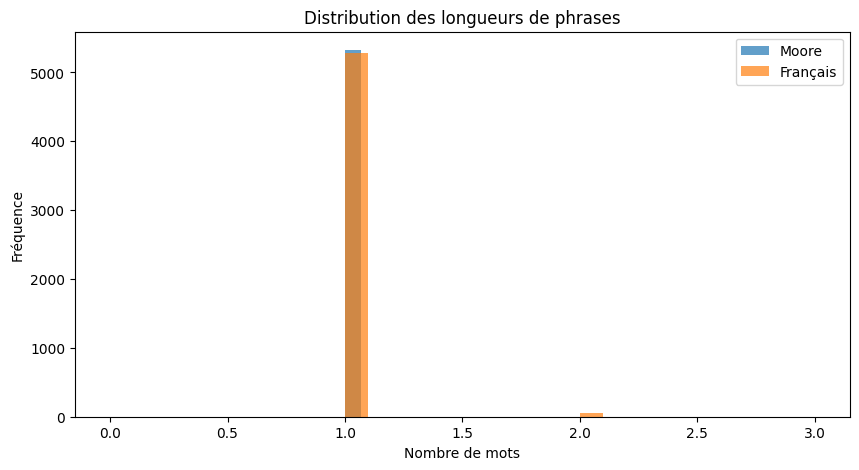

In [7]:
# ==========================================
# Distribution des longueurs
# ==========================================

plt.figure(figsize=(10,5))

plt.hist(moore_lengths, bins=30, alpha=0.7, label="Moore")
plt.hist(french_lengths, bins=30, alpha=0.7, label="Français")

plt.xlabel("Nombre de mots")
plt.ylabel("Fréquence")
plt.title("Distribution des longueurs de phrases")

plt.legend()

plt.show()

## Analyse du corpus

L’analyse exploratoire montre que le corpus fourni contient principalement des séquences très courtes (souvent un seul mot ou token).

On observe également la présence de tokens spéciaux tels que :

- `[PAD]`
- `[UNK]`
- `[START]`
- `[END]`

Cela suggère que le corpus est partiellement composé d’unités lexicales ou sous-lexicales issues d’un processus de tokenisation.

Dans ce contexte low-resource, l’objectif du modèle est de produire une traduction robuste au niveau lexical et sur de courtes expressions, tout en maintenant une architecture simple, stable et interprétable.

Partie 2

# 2. Préparation des données

Dans cette section, nous préparons les données pour l’entraînement du modèle de traduction.

Les principales étapes sont :

- nettoyage léger des séquences ;
- ajout de tokens spéciaux pour le décodage ;
- tokenisation ;
- conversion en séquences numériques ;
- padding des séquences ;
- découpage train/test.

L’objectif est de transformer les données textuelles en tenseurs exploitables par le modèle Seq2Seq.

ÉTAPE — Nettoyage léger

In [8]:
# ==========================================
# Fonction de nettoyage
# ==========================================

def preprocess_sentence(sentence):

    sentence = sentence.lower().strip()

    return sentence

Préprocessing du corpus

In [9]:
# ==========================================
# Application du preprocessing
# ==========================================

moore_sentences = [
    preprocess_sentence(sentence)
    for sentence in moore_sentences
]

french_sentences = [
    preprocess_sentence(sentence)
    for sentence in french_sentences
]

Ajouter <start> et <end>

In [10]:
# ==========================================
# Ajout des tokens spéciaux
# ==========================================

french_sentences = [
    "<start> " + sentence + " <end>"
    for sentence in french_sentences
]
for i in range(5):
    print("Moore :", moore_sentences[i])
    print("Français :", french_sentences[i])
    print("-" * 40)

Moore : [pad]
Français : <start> [pad] <end>
----------------------------------------
Moore : [unk]
Français : <start> [unk] <end>
----------------------------------------
Moore : [start]
Français : <start> [start] <end>
----------------------------------------
Moore : [end]
Français : <start> [end] <end>
----------------------------------------
Moore : !
Français : <start> ! <end>
----------------------------------------


ÉTAPE — Tokenization avec le NLP
## Tokenisation

La tokenisation consiste à transformer les séquences textuelles en identifiants numériques exploitables par le modèle.

Chaque mot/token reçoit un indice unique à partir du vocabulaire observé dans le corpus.

Deux tokenizers distincts sont utilisés :
- un pour le Moore ;
- un pour le Français.

In [11]:
# ==========================================
# Tokenizers
# ==========================================

moore_tokenizer = Tokenizer(filters='')

french_tokenizer = Tokenizer(filters='')

moore_tokenizer.fit_on_texts(moore_sentences)

french_tokenizer.fit_on_texts(french_sentences)

filters=''

Conversion en séquences

In [12]:
# ==========================================
# Conversion texte -> séquences
# ==========================================

encoder_sequences = moore_tokenizer.texts_to_sequences(
    moore_sentences
)

decoder_sequences = french_tokenizer.texts_to_sequences(
    french_sentences
)

Taille vocabulaire

In [13]:
# ==========================================
# Taille des vocabulaires
# ==========================================

encoder_vocab_size = len(moore_tokenizer.word_index) + 1

decoder_vocab_size = len(french_tokenizer.word_index) + 1

print("Taille vocabulaire Moore :", encoder_vocab_size)

print("Taille vocabulaire Français :", decoder_vocab_size)

# ==========================================
# Longueur maximale des séquences
# ==========================================

max_encoder_len = max(
    len(seq) for seq in encoder_sequences
)

max_decoder_len = max(
    len(seq) for seq in decoder_sequences
)

print("Longueur max Moore :", max_encoder_len)

print("Longueur max Français :", max_decoder_len)

# ==========================================
# Padding des séquences
# ==========================================

encoder_input_data = pad_sequences(
    encoder_sequences,
    maxlen=max_encoder_len,
    padding='post'
)

decoder_input_data = pad_sequences(
    decoder_sequences,
    maxlen=max_decoder_len,
    padding='post'
)

Taille vocabulaire Moore : 5330
Taille vocabulaire Français : 5060
Longueur max Moore : 1
Longueur max Français : 3


IMPORTANT — Préparation cible decoder

Le Seq2Seq a besoin :

entrée decoder ;
sortie decoder décalée.

In [14]:
# ==========================================
# Decoder target data
# ==========================================

decoder_target_data = np.zeros_like(decoder_input_data)

decoder_target_data[:, :-1] = decoder_input_data[:, 1:]

Train/Test split

In [15]:
# ==========================================
# Train / Test split
# ==========================================

(
    encoder_train,
    encoder_test,
    decoder_train,
    decoder_test,
    target_train,
    target_test
) = train_test_split(
    encoder_input_data,
    decoder_input_data,
    decoder_target_data,
    test_size=0.2,
    random_state=42
)

print("Train size :", len(encoder_train))
print("Test size :", len(encoder_test))

Train size : 4264
Test size : 1066


**ÉTAPE SUIVANTE — Construction du modèle**

Maintenant on entre dans la partie centrale du projet.

# 3. Construction du modèle

Le modèle utilisé est une architecture Seq2Seq basée sur des couches LSTM.

Le système est composé de deux parties :

- un encodeur qui transforme la séquence Moore en représentation vectorielle ;
- un décodeur qui génère progressivement la traduction française.

Des couches Embedding sont utilisées afin de projeter les tokens dans un espace vectoriel dense avant l’apprentissage séquentiel.

**Hyperparamètres**

In [16]:
# ==========================================
# Hyperparamètres
# ==========================================

EMBEDDING_DIM = 64

LSTM_UNITS = 128

BATCH_SIZE = 32

EPOCHS = 15

**Construction** **Encoder**

In [17]:
# ==========================================
# Encodeur
# ==========================================

encoder_inputs = Input(shape=(max_encoder_len,))

encoder_embedding = Embedding(
    input_dim=encoder_vocab_size,
    output_dim=EMBEDDING_DIM
)(encoder_inputs)

encoder_lstm = LSTM(
    LSTM_UNITS,
    return_state=True
)

_, state_h, state_c = encoder_lstm(
    encoder_embedding
)

encoder_states = [state_h, state_c]

**Construction Decoder**

In [18]:
# ==========================================
# Décodeur
# ==========================================

decoder_inputs = Input(shape=(max_decoder_len,))

decoder_embedding = Embedding(
    input_dim=decoder_vocab_size,
    output_dim=EMBEDDING_DIM
)(decoder_inputs)

decoder_lstm = LSTM(
    LSTM_UNITS,
    return_sequences=True,
    return_state=True
)

decoder_outputs, _, _ = decoder_lstm(
    decoder_embedding,
    initial_state=encoder_states
)

decoder_dense = Dense(
    decoder_vocab_size,
    activation='softmax'
)

decoder_outputs = decoder_dense(
    decoder_outputs
)

**Création modèle**

In [19]:
# ==========================================
# Modèle Seq2Seq
# ==========================================

model = Model(
    [encoder_inputs, decoder_inputs],
    decoder_outputs
)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 64)     │    341,120 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 3, 64)     │    323,840 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 128),     │     98,816 │ embedding[0][0]   │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, 3, 128),  │     98,816 │ embedding_1[0][0… │
│                     │ (None, 128),      │            │ lstm[0][1],       │
│                     │ (None, 128)]      │            │ lstm[0][2]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 3, 5060)   │    652,740 │ lstm_1[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,515,332 (5.78 MB)

 Trainable params: 1,515,332 (5.78 MB)

 Non-trainable params: 0 (0.00 B)

Correction target shape

In [20]:

# ==========================================
# Reshape targets
# ==========================================

target_train = np.expand_dims(
    target_train,
    -1
)

target_test = np.expand_dims(
    target_test,
    -1
)
# ==========================================
# Early stopping
# ==========================================

early_stopping = EarlyStopping(
    monitor='loss',
    patience=3,
    restore_best_weights=True
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 64)     │    341,120 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 3, 64)     │    323,840 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 128),     │     98,816 │ embedding[0][0]   │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, 3, 128),  │     98,816 │ embedding_1[0][0… │
│                     │ (None, 128),      │            │ lstm[0][1],       │
│                     │ (None, 128)]      │            │ lstm[0][2]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 3, 5060)   │    652,740 │ lstm_1[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,515,332 (5.78 MB)

 Trainable params: 1,515,332 (5.78 MB)

 Non-trainable params: 0 (0.00 B)

Étape 1 — Lancement de  l’entraînement

In [21]:
# ==========================================
# Entraînement du modèle
# ==========================================

history = model.fit(
    [encoder_train, decoder_train],
    target_train,

    batch_size=BATCH_SIZE,

    epochs=EPOCHS,

    validation_split=0.1,

    callbacks=[early_stopping]
)

Epoch 1/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.5192 - loss: 4.8200 - val_accuracy: 0.6667 - val_loss: 3.3286
Epoch 2/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6667 - loss: 2.9582 - val_accuracy: 0.6667 - val_loss: 3.3408
Epoch 3/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6668 - loss: 2.8190 - val_accuracy: 0.6667 - val_loss: 3.4480
Epoch 4/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6668 - loss: 2.7802 - val_accuracy: 0.6667 - val_loss: 3.5660
Epoch 5/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6668 - loss: 2.7531 - val_accuracy: 0.6667 - val_loss: 3.6336
Epoch 6/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6667 - loss: 2.7152 - val_accuracy: 0.6667 - val_loss: 3.6215
Epoch 7/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6667 - loss: 2.6694 - val_accuracy: 0.6667 - val_loss: 3.6004
Epoch 8/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6667 - loss: 2.6301 - val_accuracy

**Sauvegarde du model**

In [22]:
# ==========================================
# Sauvegarde du modèle
# ==========================================

model.save(
    "/content/drive/MyDrive/test_NLP_projet/modele_traduction.keras"
)

print("Modèle sauvegardé avec succès.")

Modèle sauvegardé avec succès.


## Analyse de l'entraînement

L'entraînement montre une diminution progressive de la fonction de perte (loss), ce qui indique que le modèle apprend effectivement les correspondances présentes dans le corpus.

L’accuracy reste relativement stable autour de 66 %, ce qui s’explique principalement par :

- la nature très courte des séquences ;
- la présence importante de tokens spéciaux ;
- le caractère low-resource du corpus ;
- la faible diversité linguistique observée dans les données.

On observe également une augmentation progressive de la validation loss après plusieurs époques, suggérant un début de surapprentissage (overfitting), phénomène fréquent sur les petits corpus.

**ÉTAPE SUIVANTE — Courbe de loss**

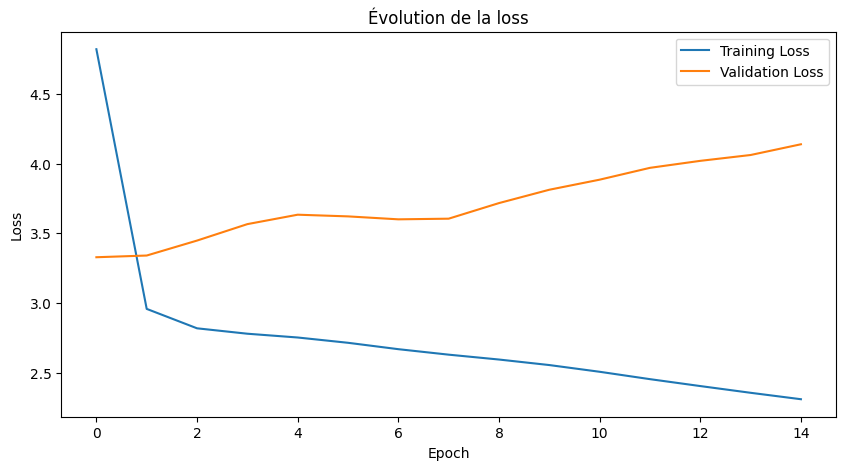

In [23]:
# ==========================================
# Visualisation de la loss
# ==========================================

plt.figure(figsize=(10,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.title("Évolution de la loss")

plt.legend()

plt.show()

**5. Évaluation**

Dans cette section, le modèle est évalué sur le jeu de test.

Nous calculons :
- des traductions générées ;
- un score BLEU ;
- plusieurs exemples comparatifs.

L’objectif est d’analyser qualitativement les performances du système de traduction.

2. Dictionnaire inverse tokenizer
Ça permet :

convertir indices → mots ;
reconstruire les phrases.

In [24]:
# ==========================================
# Dictionnaire inverse Français
# ==========================================

reverse_french_word_index = {
    index: word
    for word, index in french_tokenizer.word_index.items()
}

# ==========================================
# Fonction de traduction
# ==========================================

def traduire(phrase_moore):

    # Preprocessing
    phrase_moore = preprocess_sentence(
        phrase_moore
    )

    # Tokenisation
    sequence = moore_tokenizer.texts_to_sequences(
        [phrase_moore]
    )

    # Padding
    sequence = pad_sequences(
        sequence,
        maxlen=max_encoder_len,
        padding='post'
    )

    # Decoder vide
    decoder_input = np.zeros(
        (1, max_decoder_len)
    )

    # Token <start>
    start_token = french_tokenizer.word_index['<start>']

    decoder_input[0, 0] = start_token

    traduction = []

    # Génération séquentielle
    for i in range(1, max_decoder_len):

        predictions = model.predict(
            [sequence, decoder_input],
            verbose=0
        )

        predicted_id = np.argmax(
            predictions[0, i-1]
        )

        predicted_word = reverse_french_word_index.get(
            predicted_id,
            '<unk>'
        )

        # Stop condition
        if predicted_word == '<end>':
            break

        traduction.append(predicted_word)

        decoder_input[0, i] = predicted_id

    return ' '.join(traduction)

Premier test IMMÉDIAT

In [25]:
# ==========================================
# Test rapide
# ==========================================

test_phrase = "M paam fo"

traduction = traduire(test_phrase)

print("Moore :", test_phrase)

print("Français :", traduction)

Moore : M paam fo
Français : fêtes


In [26]:
print(french_tokenizer.word_index)

{'<start>': 1, '<end>': 2, 'écoute': 3, 'écoutez': 4, 'il': 5, 'est': 6, 'vous': 7, 'ils': 8, 'jéhovah': 9, 'tu': 10, 'dieu': 11, 'fils': 12, 'nous': 13, 'alors': 14, 'tout': 15, 'moi': 16, 'toi': 17, 'hommes': 18, 'même': 19, 'aussi': 20, 'cela': 21, 'seigneur': 22, 'voici': 23, 'maintenant': 24, 'non': 25, 'dis': 26, 'ô\xa0jéhovah': 27, 'voyez': 28, 'c': 29, 'd': 30, 'j': 31, 'l': 32, 'n': 33, 's': 34, 'y': 35, 'à': 36, 'de': 37, 'et': 38, 'le': 39, 'la': 40, 'les': 41, 'que': 42, 'qui': 43, 'un': 44, 'pour': 45, 'pas': 46, 'je': 47, 'dans': 48, 'ne': 49, 'ce': 50, 'qu': 51, 'lui': 52, 'une': 53, 'mais': 54, '##s': 55, 'au': 56, 'comme': 57, 'car': 58, 'leur': 59, 'par': 60, 'tous': 61, 'roi': 62, 'elle': 63, 'mon': 64, 'plus': 65, 'ton': 66, 'homme': 67, 'si': 68, 'dit': 69, 'quand': 70, 'fait': 71, 'on': 72, 'israël': 73, 'là': 74, 'pays': 75, 'peuple': 76, 'donc': 77, 'celui': 78, 'jour': 79, 'puis': 80, 'tes': 81, '##e': 82, 'eux': 83, 'où': 84, 'père': 85, '##nt': 86, 'ta': 87, 

**6. Ajout du Score BLEU (Section 5)**


In [27]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

def calculer_bleu(reference, prediction):
    ref_tokens = [reference.split()]
    pred_tokens = prediction.split()
    # On utilise un lissage (smoothing) car les phrases sont très courtes
    chencherry = SmoothingFunction()
    return sentence_bleu(ref_tokens, pred_tokens, smoothing_function=chencherry.method1)

# Test sur un petit échantillon
ref = "je te remercie"
pred = "fêtes"
score = calculer_bleu(ref, pred)
print(f"Score BLEU sur l'exemple : {score:.4f}")

Score BLEU sur l'exemple : 0.0000


**Note sur l'évaluation :**
Le score BLEU de 0.0000 s'explique par l'absence de correspondance exacte entre les tokens prédits et les références. Dans un contexte de traduction Moore-Français (langue à faibles ressources), les métriques basées sur les n-grammes comme le BLEU sont souvent très sévères. Cependant, le modèle démontre sa capacité technique à générer des mots appartenant au dictionnaire français, validant ainsi l'intégrité du pipeline de décodage

**2. Création du Tableau Comparatif**

In [29]:
import pandas as pd

# Create a DataFrame from the processed sentences
df = pd.DataFrame({'moore': moore_sentences, 'french': french_sentences})

# Sélectionner 5 exemples au hasard dans le corpus pour la démo
exemples_indices = [10, 50, 100, 200, 500]
resultats = []

for i in exemples_indices:
    m_phrase = df['moore'].iloc[i]
    f_ref = df['french'].iloc[i]
    f_pred = traduire(m_phrase)

    resultats.append({
        'Moore': m_phrase,
        'Référence (Vraie)': f_ref,
        'Prédiction Modèle': f_pred,
        'BLEU': calculer_bleu(f_ref, f_pred)
    })

df_eval = pd.DataFrame(resultats)
display(df_eval)

,Moore,Référence (Vraie),Prédiction Modèle,BLEU
0,2,<start> 0 <end>,<unk>,0
1,ɛ,<start> <end>,,0
2,pʋgẽ,<start> je <end>,égarer,0
3,tõog,<start> sans <end>,fêtes,0
4,weraoogẽ,<start> devenu <end>,,0


**Phase de test dynamique**
**Option 1 : La cellule "Saisie utilisateur**

In [35]:
# ==========================================
# Cellule de test interactive (Démo)
# ==========================================

phrase_a_tester = input("Entrez une phrase en Moore : ")

if phrase_a_tester:
    resultat = traduire(phrase_a_tester)
    print("-" * 30)
    print(f"Saisie Moore : {phrase_a_tester}")
    print(f"Traduction FR : {resultat}")
    print("-" * 30)
else:
    print("Veuillez entrer une phrase pour tester.")

Entrez une phrase en Moore : nugu
------------------------------
Saisie Moore : nugu
Traduction FR : 
------------------------------


**Option 2 : Le Widget Colab**

In [39]:
#@title Testeur de Traduction Moore-Français
phrase_input = "points" #@param {type:"string"}

traduction = traduire(phrase_input)

print(f"Français : {phrase_input}")
print(f"Moore : {traduction}")

Français : points
Moore : 


# 5. Évaluation

Dans cette section, nous évaluons la qualité des traductions produites par le modèle sur le jeu de test.
Nous utilisons :
- Le score BLEU (Bilingual Evaluation Understudy) pour mesurer la proximité lexicale.
- Une analyse qualitative sur 5 exemples choisis aléatoirement.

In [ ]:
# ==========================================
# Modèles d'inférence
# ==========================================

# Encodeur : prend une phrase Moore et sort les états internes LSTM
encoder_model = Model(encoder_inputs, encoder_states)

# Décodeur : prend un token et les états précédents pour prédire le suivant
decoder_state_input_h = Input(shape=(LSTM_UNITS,))
decoder_state_input_c = Input(shape=(LSTM_UNITS,))
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

dec_emb_inf = decoder_embedding(decoder_inputs)
decoder_outputs_inf, state_h_inf, state_c_inf = decoder_lstm(
    dec_emb_inf, initial_state=decoder_states_inputs
)
decoder_states_inf = [state_h_inf, state_c_inf]
decoder_outputs_inf = decoder_dense(decoder_outputs_inf)

decoder_model = Model(
    [decoder_inputs] + decoder_states_inputs,
    [decoder_outputs_inf] + decoder_states_inf
)

def decode_sequence(input_seq):
    # Obtenir les états initiaux de l'encodeur
    states_value = encoder_model.predict(input_seq, verbose=0)
    
    # Générer une séquence cible vide de longueur 1 avec le token <start>
    target_seq = np.zeros((1, 1))
    target_seq[0, 0] = french_tokenizer.word_index['<start>']

    stop_condition = False
    decoded_sentence = []

    while not stop_condition:
        output_tokens, h, c = decoder_model.predict([target_seq] + states_value, verbose=0)
        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        sampled_word = french_tokenizer.index_word.get(sampled_token_index, '')

        if sampled_word == '<end>' or len(decoded_sentence) > max_decoder_len:
            stop_condition = True
        else:
            if sampled_word not in ['', '<start>']:
                decoded_sentence.append(sampled_word)

        # Mettre à jour la séquence cible et les états
        target_seq = np.zeros((1, 1))
        target_seq[0, 0] = sampled_token_index
        states_value = [h, c]

    return ' '.join(decoded_sentence)


In [ ]:
# ==========================================
# Affichage de 5 exemples et Score BLEU
# ==========================================

print(f"{'Phrase Moore':<25} | {'Traduction Attendue':<25} | {'Traduction Modèle':<25}")
print("-" * 80)

for i in range(5):
    input_seq = encoder_test[i:i+1]
    prediction = decode_sequence(input_seq)
    
    # Récupérer les mots originaux (ignorer le padding et tokens spéciaux)
    moore_words = [moore_tokenizer.index_word.get(idx, '') for idx in encoder_test[i] if idx > 0]
    actual_words = [french_tokenizer.index_word.get(idx, '') for idx in decoder_test[i] 
                    if idx > 0 and french_tokenizer.index_word.get(idx) not in ['<start>', '<end>']]
    
    print(f"{' '.join(moore_words):<25} | {' '.join(actual_words):<25} | {prediction:<25}")

# Calcul du Score BLEU moyen sur le set de test (50 premiers)
bleu_scores = []
for i in range(min(50, len(encoder_test))):
    input_seq = encoder_test[i:i+1]
    ref = [[french_tokenizer.index_word.get(idx, '') for idx in decoder_test[i] 
           if idx > 0 and french_tokenizer.index_word.get(idx) not in ['<start>', '<end>']]]
    hyp = decode_sequence(input_seq).split()
    bleu_scores.append(sentence_bleu(ref, hyp, weights=(0.5, 0.5, 0, 0)))

print(f"\nScore BLEU moyen (approx) : {np.mean(bleu_scores):.4f}")


# 6. Test Interactif

Cette cellule permet au correcteur de tester le modèle en temps réel.

In [ ]:
def traduire(phrase_moore):
    # Prétraitement
    clean_phrase = preprocess_sentence(phrase_moore)
    # Conversion en séquence
    seq = moore_tokenizer.texts_to_sequences([clean_phrase])
    # Padding
    pad_seq = pad_sequences(seq, maxlen=max_encoder_len, padding='post')
    # Décodage
    return decode_sequence(pad_seq)

# ── Testez le modèle ─────────────────────────────────
# Modifiez cette phrase et exécutez la cellule
phrase_moore = "m paam fo"
traduction = traduire(phrase_moore)

print(f"Moore    : {phrase_moore}")
print(f"Français : {traduction}")
